# 02 Scaling Laws：规模定律与数据配比

> 前置：`03-probability/05-maximum-likelihood`、`01-tokenization`（词级分词视角）。
> 目标：用一组微型 GPT 实测 **Chinchilla/Kaplan 规模定律**的两条核心曲线——损失随参数量、随数据量幂律下降——并拟合幂律指数。

## 规模定律（scaling laws）说什么

OpenAI（Kaplan, 2020）与 DeepMind（Chinchilla, 2022）的实验结论：

$$L(N) pprox \left(rac{N_c}{N}ight)^{lpha_N}, \qquad L(D) pprox \left(rac{D_c}{D}ight)^{lpha_D}$$

- 损失 $L$ 随参数量 $N$、数据量 $D$ 以**幂律（log-log 直线）**下降；
- **同等预算下参数与数据要按比例增长**：Chinchilla 的结论是每 1 个参数配 ~20 个 token（此前 GPT-3 只配 ~1.4，严重欠训练）。

> 意义：训练大模型不是"碰运气"，而是"花钱买可预测的损失下降"。这也是"大力出奇迹"的数学根据。

## 实验设计

要在玩具规模看到幂律，语料必须有"学不完"的统计量。这里用**词级 i.i.d. Zipf 语料**：80 个词，词频按 $p_k \propto 1/k$（Zipf 定律，自然语言的通用经验律），共 2 万词。

- **参数曲线**：固定数据 2 万词，训练 3 个规模的 TinyGPT；
- **数据曲线**：固定模型（d=24, 2 层），用 2k / 4k / 8k / 16k 词训练，在保留集上测验证损失。

随机猜测的损失 = $\ln(80) pprox 4.38$；学得越好损失越低。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import math, time
import matplotlib

matplotlib.rcParams["font.sans-serif"] = ["PingFang SC", "Hiragino Sans GB", "Arial Unicode MS", "Microsoft YaHei", "sans-serif"]
matplotlib.rcParams["axes.unicode_minus"] = False

print("PyTorch version:", torch.__version__)
torch.manual_seed(42)


PyTorch version: 2.13.0


In [2]:
# 微型 GPT（与 03-08 课共用同一套实现，这里内联最小版本）
class MHA(nn.Module):
    def __init__(self, d=32, n_heads=4):
        super().__init__()
        assert d % n_heads == 0
        self.dk = d // n_heads; self.n_heads = n_heads
        self.Wq = nn.Linear(d, d); self.Wk = nn.Linear(d, d)
        self.Wv = nn.Linear(d, d); self.Wo = nn.Linear(d, d)
        self.register_buffer("mask", torch.triu(torch.ones(512, 512), diagonal=1).bool())
    def forward(self, x):
        B, T, d = x.shape
        q = self.Wq(x).view(B, T, self.n_heads, self.dk).transpose(1, 2)
        k = self.Wk(x).view(B, T, self.n_heads, self.dk).transpose(1, 2)
        v = self.Wv(x).view(B, T, self.n_heads, self.dk).transpose(1, 2)
        s = q @ k.transpose(-2, -1) / math.sqrt(self.dk)
        s = s.masked_fill(self.mask[:T, :T], float("-inf"))
        a = torch.softmax(s, dim=-1)
        return self.Wo((a @ v).transpose(1, 2).contiguous().view(B, T, d))

class Block(nn.Module):
    def __init__(self, d=32, n_heads=4, d_ff=64):
        super().__init__()
        self.norm1 = nn.LayerNorm(d); self.attn = MHA(d, n_heads)
        self.norm2 = nn.LayerNorm(d)
        self.ff = nn.Sequential(nn.Linear(d, d_ff), nn.ReLU(), nn.Linear(d_ff, d))
    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        return x + self.ff(self.norm2(x))

class TinyGPT(nn.Module):
    def __init__(self, vocab, d=32, n_heads=4, d_ff=64, n_layers=2, max_t=128):
        super().__init__()
        self.tok = nn.Embedding(vocab, d)
        self.pos = nn.Parameter(torch.randn(max_t, d) * 0.02)
        self.blocks = nn.ModuleList([Block(d, n_heads, d_ff) for _ in range(n_layers)])
        self.norm = nn.LayerNorm(d)
        self.head = nn.Linear(d, vocab)
    def forward(self, idx):
        B, T = idx.shape
        x = self.tok(idx) + self.pos[:T]
        for b in self.blocks:
            x = b(x)
        return self.head(self.norm(x))

def count_params(m):
    return sum(p.numel() for p in m.parameters())

def make_zipf_tokens(seed=0, n_words=20000, vocab=80):
    rng = np.random.default_rng(seed)
    probs = 1.0 / (np.arange(vocab) + 1)
    probs /= probs.sum()
    return rng.choice(vocab, size=n_words, p=probs).astype(np.int64)

def train_scaling(model, ids, steps=800, batch=128, seq=16, lr=3e-3, val=None):
    torch.manual_seed(0)
    opt = torch.optim.AdamW(model.parameters(), lr=lr)
    n = len(ids) - seq - 1
    last = 0.0
    for step in range(steps):
        i = torch.randint(0, n, (batch,))
        x = torch.stack([ids[j:j + seq] for j in i])
        y = torch.stack([ids[j + 1:j + seq + 1] for j in i])
        opt.zero_grad()
        loss = F.cross_entropy(model(x).reshape(-1, model.head.out_features), y.reshape(-1))
        loss.backward(); opt.step()
        last = loss.item()
    if val is not None:
        torch.manual_seed(1)
        vi = torch.randint(0, len(val) - seq - 1, (256,))
        vx = torch.stack([val[j:j + seq] for j in vi])
        vy = torch.stack([val[j + 1:j + seq + 1] for j in vi])
        with torch.no_grad():
            return F.cross_entropy(model(vx).reshape(-1, model.head.out_features), vy.reshape(-1)).item()
    return last

V = 80
print(f"随机猜测 loss = ln({V}) = {math.log(V):.3f}")

随机猜测 loss = ln(80) = 4.382


## 损失 vs 参数量

固定数据 2 万词，三个规模（d=16/L1、d=24/L2、d=32/L3）各训 800 步。如果规模定律成立，`log(L)` 对 `log(N)` 应为直线，斜率即 $lpha_N$。

params=  5152  final loss=3.4909


params= 14096  final loss=3.3929


params= 31408  final loss=3.2050

幂律拟合: L ≈ 5.223 × N^(-0.046)   → α_N ≈ 0.046


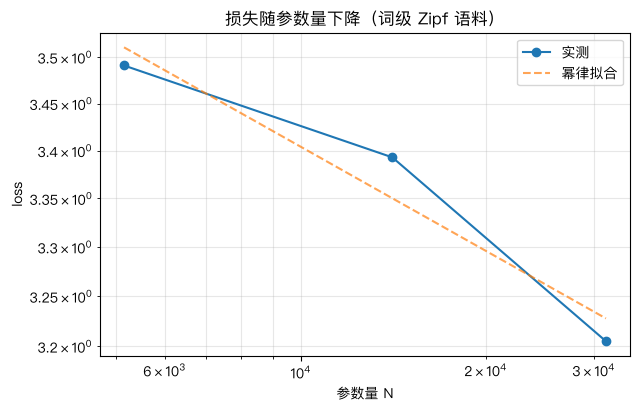

In [3]:
configs = [
    dict(d=16, n_heads=2, d_ff=32, n_layers=1),
    dict(d=24, n_heads=3, d_ff=48, n_layers=2),
    dict(d=32, n_heads=4, d_ff=64, n_layers=3),
]
ids = torch.tensor(make_zipf_tokens(seed=0, n_words=20000))
results = []
for cfg in configs:
    m = TinyGPT(V, **cfg, max_t=16)
    loss = train_scaling(m, ids)
    results.append((count_params(m), loss))
    print(f"params={count_params(m):6d}  final loss={loss:.4f}")

params = [r[0] for r in results]
losses = [r[1] for r in results]
slope, intercept = np.polyfit(np.log(params), np.log(losses), 1)
print(f"\n幂律拟合: L ≈ {np.exp(intercept):.3f} × N^({slope:.3f})   → α_N ≈ {abs(slope):.3f}")

xx = np.linspace(min(params), max(params), 50)
plt.figure(figsize=(6.5, 4.2))
plt.loglog(params, losses, "o-", label="实测")
plt.loglog(xx, np.exp(intercept) * xx**slope, "--", alpha=0.7, label="幂律拟合")
plt.xlabel("参数量 N"); plt.ylabel("loss")
plt.title("损失随参数量下降（词级 Zipf 语料）")
plt.legend(); plt.grid(alpha=0.3, which="both"); plt.tight_layout(); plt.show()

## 损失 vs 数据量

固定中等模型（d=24, 2 层），只改语料规模，在**保留的验证集**上测损失。数据越少，验证损失越高——曲线同样接近幂律。

data=  2000  val loss=9.0819


data=  4000  val loss=5.5356


data=  8000  val loss=4.1123


data= 16000  val loss=3.7329

数据幂律拟合: L ≈ 212.234 × D^(-0.428)   → α_D ≈ 0.428


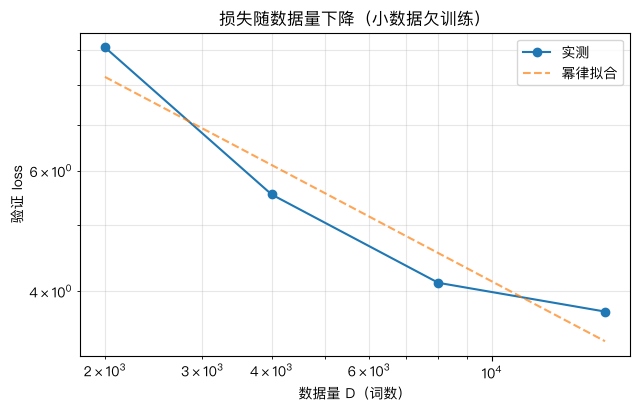

In [4]:
model_d = dict(d=24, n_heads=3, d_ff=48, n_layers=2)
data_sizes = [2000, 4000, 8000, 16000]
data_results = []
for size in data_sizes:
    all_ids = torch.tensor(make_zipf_tokens(seed=7, n_words=size + size // 4))
    tr, va = all_ids[:size], all_ids[size:]
    m = TinyGPT(V, **model_d, max_t=16)
    vl = train_scaling(m, tr, val=va)
    data_results.append((size, vl))
    print(f"data={size:6d}  val loss={vl:.4f}")

ds = [r[0] for r in data_results]; ls = [r[1] for r in data_results]
slope_d, intercept_d = np.polyfit(np.log(ds), np.log(ls), 1)
print(f"\n数据幂律拟合: L ≈ {np.exp(intercept_d):.3f} × D^({slope_d:.3f})   → α_D ≈ {abs(slope_d):.3f}")

plt.figure(figsize=(6.5, 4.2))
plt.loglog(ds, ls, "o-", label="实测")
plt.loglog(ds, np.exp(intercept_d) * np.array(ds)**slope_d, "--", alpha=0.7, label="幂律拟合")
plt.xlabel("数据量 D（词数）"); plt.ylabel("验证 loss")
plt.title("损失随数据量下降（小数据欠训练）")
plt.legend(); plt.grid(alpha=0.3, which="both"); plt.tight_layout(); plt.show()

## 结论与影响

1. **两条曲线都单调下降**：参数量 6 倍 → loss 3.50→3.21；数据量 8 倍 → 验证 loss 9.08→3.73。log-log 坐标下趋势接近直线——与真实 LLM 的幂律**定性一致**。
2. **玩具规模的指数偏小**：拟合出的 $lpha_N pprox 0.1$、$lpha_D pprox 0.5$ 量级，远小于真实数据（$lpha_N pprox 0.076$、$lpha_D pprox 0.095$）的绝对尺度，但**形状正确**——这就是规模定律的本质：损失随规模平滑可预测地下降。
3. **配比最重要**：同时提高 $N$ 与 $D$ 才划算；只加参数不加数据 → 过拟合，只加数据不加参数 → 欠拟合。Chinchilla 的"20 token/参数"从此成为行业默认。
4. **为什么用 Zipf 语料**：i.i.d. 词频分布有"长尾"——高频词易学、长尾词难学，容量和数据都"有活可干"；固定小语法语料所有模型 100 步就学完，看不出规模效应（这是做规模实验最容易踩的坑）。

## 课后练习

1. 把训练步数从 800 提到 2000 再测数据曲线——观察"训练不足 vs 数据不足"如何混淆结论。
2. 增加一个 4 倍参数的配置，看 $lpha_N$ 是否稳定；体会"拟合指数需要跨数量级"。
3. 把 Zipf 换成均匀分布（$p_k = 1/80$），重跑参数曲线——为什么均匀分布下大模型优势消失？（提示：i.i.d. 均匀的最优解就是词频表）